# RPL Dashboard - Data Loading & Dual DataFrame Analysis (KH & EN)

This notebook performs exploratory data analysis (EDA), data cleaning, and visualization generation for the RPL dataset.

- **`df_kh`**: Contains cleaned data with Khmer attributes (`Gender_KH`, `Occupation_KH`, `NQ_KH`, `AT_KH`) for internal analysis.
- **`df_en`**: Contains cleaned data with English attributes (`Gender_EN`, `Occupation_EN`, `NQ_EN`, `AT_EN`) for summary tables and charts.

In [106]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Configure matplotlib style
plt.style.use('seaborn-v0_8-whitegrid') if 'seaborn-v0_8-whitegrid' in plt.style.available else plt.style.use('default')
plt.rcParams['font.size'] = 10

## 1. Raw Data Loading
Load the raw dataset `RPL_Dashboard_V.1.csv` into a Pandas DataFrame.

In [107]:
# Load raw dataset
df_raw = pd.read_csv('RPL_Dashboard_V.1.csv')
print(f"Raw Dataset Shape: {df_raw.shape[0]} rows, {df_raw.shape[1]} columns")
df_raw.head(3)

Raw Dataset Shape: 1405 rows, 33 columns


,No,Serial_Code,Number,FullName,Latin,Gender_KH,Gender_EN,DOB,DOB_Day_KH,DOB_Month_KH,...,CM_Year_KH,Date_Issue_EN,DI_Day_KH,DI_Month_KH,DI_Year_KH,Date_Expiry_EN,DE_Day_KH,DE_Month_KH,DE Year (KH),Sponsors
0,1,BEW1-,1,វ៉ាន បញ្ញា,VAN PANHA,ប្រុស,Male,1-Apr-01,១,មេសា,...,២០២០,16-Nov-20,១៦,វិច្ឆិកា,២០២០,16-Nov-25,១៦,វិច្ឆិកា,២០២៥,PB-2020
1,1,MAS1-,2,ប៉ិច សំអុន,PICH SAMON,ប្រុស,Male,11-Sep-79,១១,កញ្ញា,...,២០២០,16-Nov-20,១៦,វិច្ឆិកា,២០២០,16-Nov-25,១៦,វិច្ឆិកា,២០២៥,PB-2020
2,1,PLU2-,3,ស៊ុយ ច័ន្ទ,SUY CHANN,ប្រុស,Male,3-Jun-81,៣,មិថុនា,...,២០២០,16-Nov-20,១៦,វិច្ឆិកា,២០២០,16-Nov-25,១៦,វិច្ឆិកា,២០២៥,PB-2020


## 2. Separate into 2 DataFrames: `df_kh` and `df_en` 
1. Apply common column drops (`Serial_Code`, `Path`, `Pics`, `CardNo`, `CM_Day_KH`, `CM_Month_KH`, `CM_Year_KH`, and all Date Issue/Expiry sub-columns).
2. Create **`df_kh`**: Keeps Khmer target attributes (`Gender_KH`, `Occupation_KH`, `NQ_KH`, `AT_KH`) and drops `_EN` columns.
3. Create **`df_en`**: Keeps English target attributes (`Gender_EN`, `Occupation_EN`, `NQ_EN`, `AT_EN`) and drops `KH` target columns.

In [108]:
# Common column drops
explicit_drops = ['Serial_Code', 'Path', 'Pics', 'CardNo']
cm_cols = ['CM_Day_KH', 'CM_Month_KH', 'CM_Year_KH']
di_cols = [c for c in df_raw.columns if c.startswith('DI') or 'Date_Issue' in c]
de_cols = [c for c in df_raw.columns if c.startswith('DE') or 'Date_Expiry' in c]

common_drops = list(set(explicit_drops + cm_cols + di_cols + de_cols))

# 1. Create df_kh (Khmer DataFrame - drop EN columns)
en_cols = [c for c in df_raw.columns if c.endswith('_EN')]
df_kh = df_raw.drop(columns=[c for c in (common_drops + en_cols) if c in df_raw.columns]).copy()

# 2. Create df_en (English DataFrame - drop target KH columns)
kh_target_cols = ['Gender_KH', 'Occupation_KH', 'NQ_KH', 'AT_KH']
df_en = df_raw.drop(columns=[c for c in (common_drops + kh_target_cols) if c in df_raw.columns]).copy()

# Extract CM_Date & CM_Year attributes for time-based exploration
df_kh['CM_Date'] = pd.to_datetime(df_kh['Date_Committee_Meeting'], format='%d-%b-%y', errors='coerce')
df_kh['CM_Year'] = df_kh['CM_Date'].dt.year

df_en['CM_Date'] = pd.to_datetime(df_en['Date_Committee_Meeting'], format='%d-%b-%y', errors='coerce')
df_en['CM_Year'] = df_en['CM_Date'].dt.year

print(f"df_kh Shape: {df_kh.shape[0]} rows, {df_kh.shape[1]} columns")
print(f"df_kh Columns: {df_kh.columns.tolist()}")

print(f"\ndf_en Shape: {df_en.shape[0]} rows, {df_en.shape[1]} columns")
print(f"df_en Columns: {df_en.columns.tolist()}")

df_kh Shape: 1405 rows, 16 columns
df_kh Columns: ['No', 'Number', 'FullName', 'Latin', 'Gender_KH', 'DOB', 'DOB_Day_KH', 'DOB_Month_KH', 'DOB_Year_KH', 'Occupation_KH', 'NQ_KH', 'AT_KH', 'Date_Committee_Meeting', 'Sponsors', 'CM_Date', 'CM_Year']

df_en Shape: 1405 rows, 16 columns
df_en Columns: ['No', 'Number', 'FullName', 'Latin', 'Gender_EN', 'DOB', 'DOB_Day_KH', 'DOB_Month_KH', 'DOB_Year_KH', 'Occupation_EN', 'NQ_EN', 'AT_EN', 'Date_Committee_Meeting', 'Sponsors', 'CM_Date', 'CM_Year']


## 3. Internal Data Exploration & Crosstabs (`df_kh`)
Exploring candidate data internally using Khmer attributes (`df_kh`).

In [109]:
# Display first 5 rows of df_kh
df_kh.head()

,No,Number,FullName,Latin,Gender_KH,DOB,DOB_Day_KH,DOB_Month_KH,DOB_Year_KH,Occupation_KH,NQ_KH,AT_KH,Date_Committee_Meeting,Sponsors,CM_Date,CM_Year
0,1,1,វ៉ាន បញ្ញា,VAN PANHA,ប្រុស,1-Apr-01,១,មេសា,២០០១,ការផ្សាអគ្គិសនី,វិញ្ញាបនបត្រវិជ្ជាជីវៈ,វិទ្យាស្ថានបច្ចេកទេសឧស្សាហកម្ម,16-Nov-20,PB-2020,2020-11-16,2020
1,1,2,ប៉ិច សំអុន,PICH SAMON,ប្រុស,11-Sep-79,១១,កញ្ញា,១៩៧៩,ការផ្សាអគ្គិសនី,វិញ្ញាបនបត្រវិជ្ជាជីវៈ,វិទ្យាស្ថានបច្ចេកទេសឧស្សាហកម្ម,16-Nov-20,PB-2020,2020-11-16,2020
2,1,3,ស៊ុយ ច័ន្ទ,SUY CHANN,ប្រុស,3-Jun-81,៣,មិថុនា,១៩៨១,ការផ្សាអគ្គិសនី,វិញ្ញាបនបត្រវិជ្ជាជីវៈ,វិទ្យាស្ថានបច្ចេកទេសឧស្សាហកម្ម,16-Nov-20,PB-2020,2020-11-16,2020
3,2,4,គឹម ឡាយ,KIM LAY,ប្រុស,3-Jun-81,៣,មិថុនា,១៩៨១,ការផ្សាអគ្គិសនី,វិញ្ញាបនបត្រវិជ្ជាជីវៈ,វិទ្យាស្ថានបច្ចេកទេសឧស្សាហកម្ម,16-Nov-20,PB-2020,2020-11-16,2020
4,2,5,សាលី សាវ៉ាត,SALY SAVATH,ប្រុស,12-Mar-86,១២,មីនា,១៩៨៦,ការផ្សាអគ្គិសនី,វិញ្ញាបនបត្រវិជ្ជាជីវៈ,វិទ្យាស្ថានបច្ចេកទេសឧស្សាហកម្ម,16-Nov-20,PB-2020,2020-11-16,2020


In [110]:
print("=== 1. Overall Gender Total (KH) ===")
gender_kh_df = pd.crosstab(df_kh['Gender_KH'], columns='Count')
gender_kh_df['Percentage (%)'] = (gender_kh_df['Count'] / len(df_kh) * 100).round(2)
gender_kh_df.loc['Total'] = [len(df_kh), 100.0]
display(gender_kh_df)

print("\n=== 2. Occupation Breakdown per Gender (KH) ===")
occ_kh_ct = pd.crosstab(df_kh['Occupation_KH'], df_kh['Gender_KH'], margins=True, margins_name='Total')
display(occ_kh_ct.sort_values(by='Total', ascending=False))

print("\n=== 3. Assessment Center Breakdown per Gender (KH) ===")
at_kh_ct = pd.crosstab(df_kh['AT_KH'], df_kh['Gender_KH'], margins=True, margins_name='Total')
display(at_kh_ct.sort_values(by='Total', ascending=False))

print("\n=== 4. National Qualification Breakdown per Gender (KH) ===")
nq_kh_ct = pd.crosstab(df_kh['NQ_KH'], df_kh['Gender_KH'], margins=True, margins_name='Total')
display(nq_kh_ct.sort_values(by='Total', ascending=False))

print("\n=== 5. Sponsor Breakdown per Gender (KH) ===")
sp_kh_ct = pd.crosstab(df_kh['Sponsors'], df_kh['Gender_KH'], margins=True, margins_name='Total')
display(sp_kh_ct.sort_values(by='Total', ascending=False))

print("\n=== 6. Year Breakdown per Gender (KH) ===")
year_kh_ct = pd.crosstab(df_kh['CM_Year'], df_kh['Gender_KH'], margins=True, margins_name='Total')
display(year_kh_ct)

print("\n=== 7. Occupation Breakdown per Year (KH) ===")
occ_yr_kh = pd.crosstab(df_kh['Occupation_KH'], df_kh['CM_Year'], margins=True, margins_name='Total')
display(occ_yr_kh.sort_values(by='Total', ascending=False))

print("\n=== 8. Assessment Center Breakdown per Year (KH) ===")
at_yr_kh = pd.crosstab(df_kh['AT_KH'], df_kh['CM_Year'], margins=True, margins_name='Total')
display(at_yr_kh.sort_values(by='Total', ascending=False))

=== 1. Overall Gender Total (KH) ===


col_0,Count,Percentage (%)
Gender_KH,,
ប្រុស,1200.0,85.41
ស្រី,205.0,14.59
Total,1405.0,100.00



=== 2. Occupation Breakdown per Gender (KH) ===


Gender_KH,ប្រុស,ស្រី,Total
Occupation_KH,,,
Total,1200,205,1405
ការដំឡើងបណ្តាញអគ្គិសនីក្នុងអគារ,456,96,552
ការងារកំបោរ,322,4,326
រចនាក្រាហ្វិកដោយកុំព្យូទ័រ,80,55,135
សេវាកម្មកុំព្យូទ័រ,69,21,90
ការងារដំឡើងពុម្ព,79,2,81
ការផ្សាអគ្គិសនី,51,0,51
ការកែច្នៃបន្លែ និងផ្លែឈើ,21,19,40
ការបន្ស៊ីលោហៈ,39,0,39



=== 3. Assessment Center Breakdown per Gender (KH) ===


...

Gender_KH,ប្រុស,ស្រី,Total
CM_Year,,,
2020,669,86,755
2021,198,66,264
2022,164,38,202
2023,169,15,184
Total,1200,205,1405



=== 7. Occupation Breakdown per Year (KH) ===


CM_Year,2020,2021,2022,2023,Total
Occupation_KH,,,,,
Total,755,264,202,184,1405
ការដំឡើងបណ្តាញអគ្គិសនីក្នុងអគារ,277,105,89,81,552
ការងារកំបោរ,178,38,56,54,326
រចនាក្រាហ្វិកដោយកុំព្យូទ័រ,69,39,24,3,135
សេវាកម្មកុំព្យូទ័រ,42,29,14,5,90
ការងារដំឡើងពុម្ព,24,16,0,41,81
ការផ្សាអគ្គិសនី,25,17,9,0,51
ការកែច្នៃបន្លែ និងផ្លែឈើ,26,14,0,0,40
ការបន្ស៊ីលោហៈ,39,0,0,0,39



=== 8. Assessment Center Breakdown per Year (KH) ===


CM_Year,2020,2021,2022,2023,Total
AT_KH,,,,,
Total,755,264,202,184,1405
មជ្ឈមណ្ឌលវាយតម្លៃសមត្ថភាពព្រះកុសុមៈ,209,200,0,100,509
មជ្ឈមណ្ឌលវាយតម្លៃសមត្ថភាពបាត់ដំបង,127,25,33,84,269
មជ្ឈមណ្ឌលវាយតម្លៃសមត្ថភាពអង្គរ,163,0,48,0,211
មជ្ឈមណ្ឌលវាយតម្លៃសមត្ថភាពខេត្តក្រចេះ,52,25,75,0,152
មជ្ឈមណ្ឌលវាយតម្លៃសមត្ថភាពខេត្តតាកែវ,104,0,46,0,150
វិទ្យាស្ថានជាតិពហុបច្ចេកទេសកម្ពុជា,60,0,0,0,60
វិទ្យាស្ថានបច្ចេកទេសឧស្សាហកម្ម,40,0,0,0,40
វិទ្យាស្ថានជាតិវីជ្ជាជីវៈបាត់ដំបង,0,14,0,0,14


## 4. Visualization Tables & Charts (`df_en`)
Using **`df_en`** (dropping KH target columns) to generate summary tables and clean matplotlib visual charts.

In [111]:
# Display first 5 rows of df_en
df_en.head()

,No,Number,FullName,Latin,Gender_EN,DOB,DOB_Day_KH,DOB_Month_KH,DOB_Year_KH,Occupation_EN,NQ_EN,AT_EN,Date_Committee_Meeting,Sponsors,CM_Date,CM_Year
0,1,1,វ៉ាន បញ្ញា,VAN PANHA,Male,1-Apr-01,១,មេសា,២០០១,Arc Welding,Vocational Certificate,Industrial Technology Institute,16-Nov-20,PB-2020,2020-11-16,2020
1,1,2,ប៉ិច សំអុន,PICH SAMON,Male,11-Sep-79,១១,កញ្ញា,១៩៧៩,Arc Welding,Vocational Certificate,Industrial Technology Institute,16-Nov-20,PB-2020,2020-11-16,2020
2,1,3,ស៊ុយ ច័ន្ទ,SUY CHANN,Male,3-Jun-81,៣,មិថុនា,១៩៨១,Arc Welding,Vocational Certificate,Industrial Technology Institute,16-Nov-20,PB-2020,2020-11-16,2020
3,2,4,គឹម ឡាយ,KIM LAY,Male,3-Jun-81,៣,មិថុនា,១៩៨១,Arc Welding,Vocational Certificate,Industrial Technology Institute,16-Nov-20,PB-2020,2020-11-16,2020
4,2,5,សាលី សាវ៉ាត,SALY SAVATH,Male,12-Mar-86,១២,មីនា,១៩៨៦,Arc Welding,Vocational Certificate,Industrial Technology Institute,16-Nov-20,PB-2020,2020-11-16,2020


In [112]:
print("=== 1. Overall Gender Total (EN) ===")
gender_en_df = pd.crosstab(df_en['Gender_EN'], columns='Candidate Count')
gender_en_df['Percentage (%)'] = (gender_en_df['Candidate Count'] / len(df_en) * 100).round(2)
gender_en_df.loc['Total'] = [len(df_en), 100.0]
display(gender_en_df)

print("\n=== 2. Occupation Breakdown per Gender (EN) ===")
occ_en_ct = pd.crosstab(df_en['Occupation_EN'], df_en['Gender_EN'], margins=True, margins_name='Total')
occ_en_ct = occ_en_ct[['Male', 'Female', 'Total']].sort_values(by='Total', ascending=False)
display(occ_en_ct)

print("\n=== 3. Assessment Center Breakdown per Gender (EN) ===")
at_en_ct = pd.crosstab(df_en['AT_EN'], df_en['Gender_EN'], margins=True, margins_name='Total')
at_en_ct = at_en_ct[['Male', 'Female', 'Total']].sort_values(by='Total', ascending=False)
display(at_en_ct)

print("\n=== 4. National Qualification Breakdown per Gender (EN) ===")
nq_en_ct = pd.crosstab(df_en['NQ_EN'], df_en['Gender_EN'], margins=True, margins_name='Total')
nq_en_ct = nq_en_ct[['Male', 'Female', 'Total']].sort_values(by='Total', ascending=False)
display(nq_en_ct)

print("\n=== 5. Sponsor Breakdown per Gender (EN) ===")
sp_en_ct = pd.crosstab(df_en['Sponsors'], df_en['Gender_EN'], margins=True, margins_name='Total')
sp_en_ct = sp_en_ct[['Male', 'Female', 'Total']].sort_values(by='Total', ascending=False)
display(sp_en_ct)

print("\n=== 6. Year Breakdown per Gender (EN) ===")
year_en_ct = pd.crosstab(df_en['CM_Year'], df_en['Gender_EN'], margins=True, margins_name='Total')
year_en_ct = year_en_ct[['Male', 'Female', 'Total']]
display(year_en_ct)

print("\n=== 7. Occupation Breakdown per Year (EN) ===")
occ_yr_en = pd.crosstab(df_en['Occupation_EN'], df_en['CM_Year'], margins=True, margins_name='Total')
display(occ_yr_en.sort_values(by='Total', ascending=False))

print("\n=== 8. Assessment Center Breakdown per Year (EN) ===")
at_yr_en = pd.crosstab(df_en['AT_EN'], df_en['CM_Year'], margins=True, margins_name='Total')
display(at_yr_en.sort_values(by='Total', ascending=False))

print("\n=== 9. Qualification Level (NQ) Breakdown per Year (EN) ===")
nq_yr_en = pd.crosstab(df_en['NQ_EN'], df_en['CM_Year'], margins=True, margins_name='Total')
display(nq_yr_en.sort_values(by='Total', ascending=False))

print("\n=== 10. Sponsor Breakdown per Year (EN) ===")
sp_yr_en = pd.crosstab(df_en['Sponsors'], df_en['CM_Year'], margins=True, margins_name='Total')
display(sp_yr_en.sort_values(by='Total', ascending=False))

print("\n=== 11. Occupation Gender Divergence per Year (EN) ===")
occ_yr_gen_en = pd.crosstab(df_en['Occupation_EN'], [df_en['CM_Year'], df_en['Gender_EN']], margins=True, margins_name='Total')
display(occ_yr_gen_en)

print("\n=== 12. Assessment Center Gender Divergence per Year (EN) ===")
at_yr_gen_en = pd.crosstab(df_en['AT_EN'], [df_en['CM_Year'], df_en['Gender_EN']], margins=True, margins_name='Total')
display(at_yr_gen_en)

=== 1. Overall Gender Total (EN) ===


col_0,Candidate Count,Percentage (%)
Gender_EN,,
Female,204.0,14.52
Male,1201.0,85.48
Total,1405.0,100.00



=== 2. Occupation Breakdown per Gender (EN) ===


Gender_EN,Male,Female,Total
Occupation_EN,,,
Total,1201,204,1405
Building Electrical Wiring,456,96,552
Masonry,322,4,326
Graphic Design,80,55,135
Computer Servicing,69,21,90
Rough Carpentry,79,2,81
Arc Welding,51,0,51
Fruit and Vegetable Processing,21,19,40
Machining,39,0,39



=== 3. Assessment Center Breakdown per Gender (EN) ===


...

CM_Year,2020,2021,2022,2023,Total
Sponsors,,,,,
Total,755,264,202,184,1405
PB-2020,536,0,0,0,536
TVETSDP,0,125,147,0,272
Other,219,0,0,0,219
PB-2022,0,0,0,100,100
PB-2021,0,100,0,0,100
ILO-2023,0,0,0,84,84
Swiss-Contact,0,0,55,0,55
PIN,0,39,0,0,39



=== 11. Occupation Gender Divergence per Year (EN) ===


CM_Year                                 2020        2021        2022       \
Gender_EN                             Female Male Female Male Female Male   
Occupation_EN                                                               
Arc Welding                                0   25      0   17      0    9   
Automotive Servicing                       0   16      0    5      0    6   
Automotive air-conditioning servicing      0    6      0    0      0    0   
Automotive electrical Servicing            0   12      0    1      0    1   
Baking                                     6    4      0    0      0    0   
Building Electrical Wiring                34  243     30   75     22   67   
Computer Servicing                         6   36      8   21      5    9   
Fruit and Vegetable Processing             8   18     11    3      0    0   
Graphic Design                            27   42     16   23     11   13   
Machining                                  0   39      0    0      0    0   
Masonry                                    2  176      1   37      0   56   
Plumbing                                   1   30      0    0      0    3   
Rough Carpentry                            1   23      0   16      0    0   
Total                                     85  670     66  198     38  164   

CM_Year                                 2023      Total  
Gender_EN                             Female Male        
Occupation_EN                                            
Arc Welding                                0    0    51  
Automotive Servicing                       0    0    27  
Automotive air-conditioning servicing      0    0     6  
Automotive electrical Servicing            0    0    14  
Baking                                     0    0    10  
Building Electrical Wiring                10   71   552  
Computer Servicing                         2    3    90  
Fruit and Vegetable Processing             0    0    40  
Graphic Design                             1    2   135  
Machining                                  0    0    39  
Masonry                                    1   53   326  
Plumbing                                   0    0    34  
Rough Carpentry                            1   40    81  
Total                                     15  169  1405


=== 12. Assessment Center Gender Divergence per Year (EN) ===


CM_Year                                       2020        2021        2022  \
Gender_EN                                   Female Male Female Male Female   
AT_EN                                                                        
Angkor Competency Assessment Center              8  155      0    0      9   
Battambang Competency Assessment Center         18  109      6   19     10   
Industrial Technology Institute                  0   40      0    0      0   
Kratie Competency Assessment Center              0   52      0   25      8   
National Polytechnic Institute of Cambodia      14   46      0    0      0   
National Vocational Institute of Battambang      0    0     11    3      0   
Preah Kossomak Competency Assessment Center     29  180     49  151      0   
Takeo Competency Assessment Center              16   88      0    0     11   
Total                                           85  670     66  198     38   

CM_Year                                            2023      Total  
Gender_EN                                   Male Female Male        
AT_EN                                                               
Angkor Competency Assessment Center           39      0    0   211  
Battambang Competency Assessment Center       23      4   80   269  
Industrial Technology Institute                0      0    0    40  
Kratie Competency Assessment Center           67      0    0   152  
National Polytechnic Institute of Cambodia     0      0    0    60  
National Vocational Institute of Battambang    0      0    0    14  
Preah Kossomak Competency Assessment Center    0     11   89   509  
Takeo Competency Assessment Center            35      0    0   150  
Total                                        164     15  169  1405

### 4.1 Overall Gender Distribution Visualization
Visualizing total Male vs Female candidate counts alongside the Total column, featuring percentage values and clear annotations.

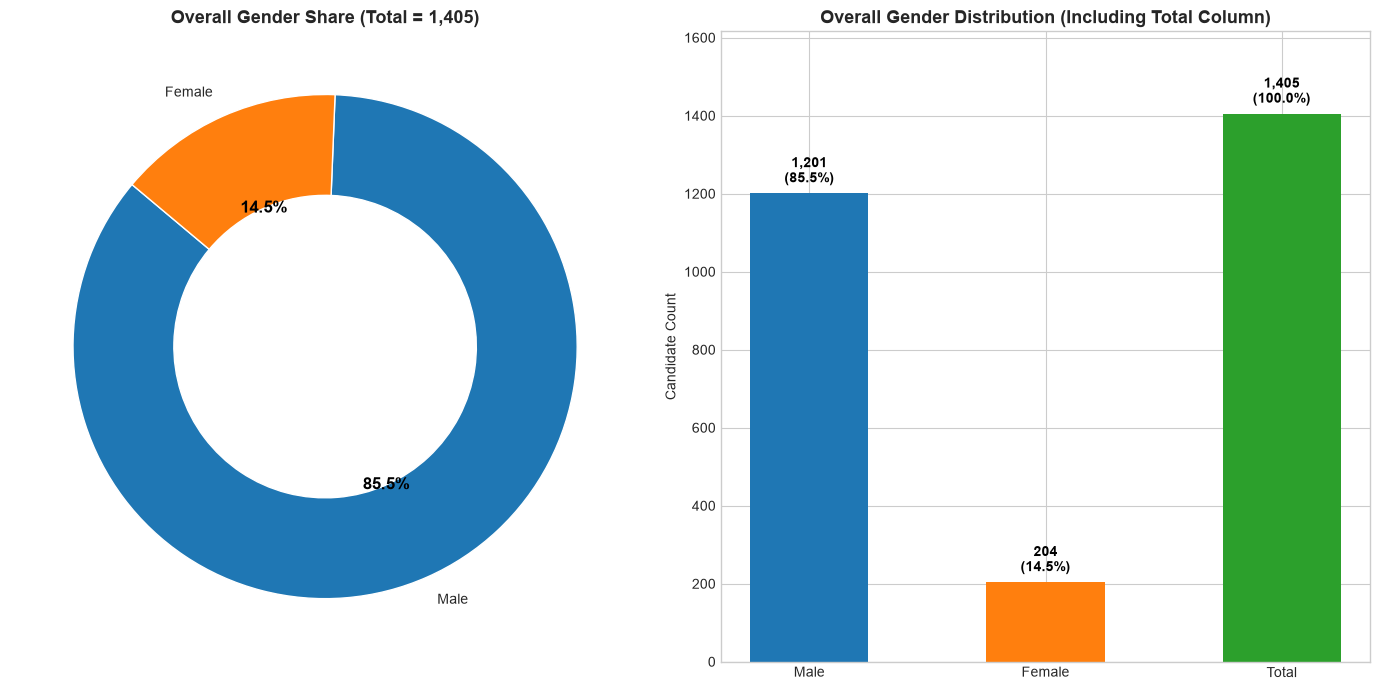

In [113]:
# Dedicated Overall Gender Donut Chart & Column Bar Chart (including Total Column)
fig, axes = plt.subplots(1, 2, figsize=(14, 7))

gender_counts = df_en['Gender_EN'].value_counts()
colors = ['#1f77b4', '#ff7f0e']

# Subplot 1: Donut Chart
wedges, texts, autotexts = axes[0].pie(
    gender_counts, 
    labels=gender_counts.index, 
    autopct='%1.1f%%',
    startangle=140,
    colors=colors,
    wedgeprops=dict(width=0.4, edgecolor='w')
)
for autotext in autotexts:
    autotext.set_color('black')
    autotext.set_weight('bold')
    autotext.set_fontsize(12)

axes[0].set_title(f'Overall Gender Share (Total = {len(df_en):,})', fontsize=13, fontweight='bold')

# Subplot 2: Bar Column Chart INCLUDING Male, Female, and TOTAL columns
categories = ['Male', 'Female', 'Total']
values = [gender_counts.get('Male', 0), gender_counts.get('Female', 0), len(df_en)]
bar_colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

bars = axes[1].bar(categories, values, color=bar_colors, width=0.5)
axes[1].set_title('Overall Gender Distribution (Including Total Column)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Candidate Count')
axes[1].set_ylim(0, len(df_en) * 1.15)

for bar in bars:
    height = bar.get_height()
    pct = (height / len(df_en)) * 100
    axes[1].annotate(f'{height:,}\n({pct:.1f}%)',
                     xy=(bar.get_x() + bar.get_width() / 2, height),
                     xytext=(0, 5),
                     textcoords="offset points",
                     ha='center', va='bottom', fontweight='bold', color='black')

plt.tight_layout()
plt.show()

### 4.2 Breakdown Visualizations across Categories
Stacked bar charts comparing Male vs Female distribution across Occupations, Assessment Centers, NQ Levels, and Sponsors, complete with exact numerical labels on each column segment.

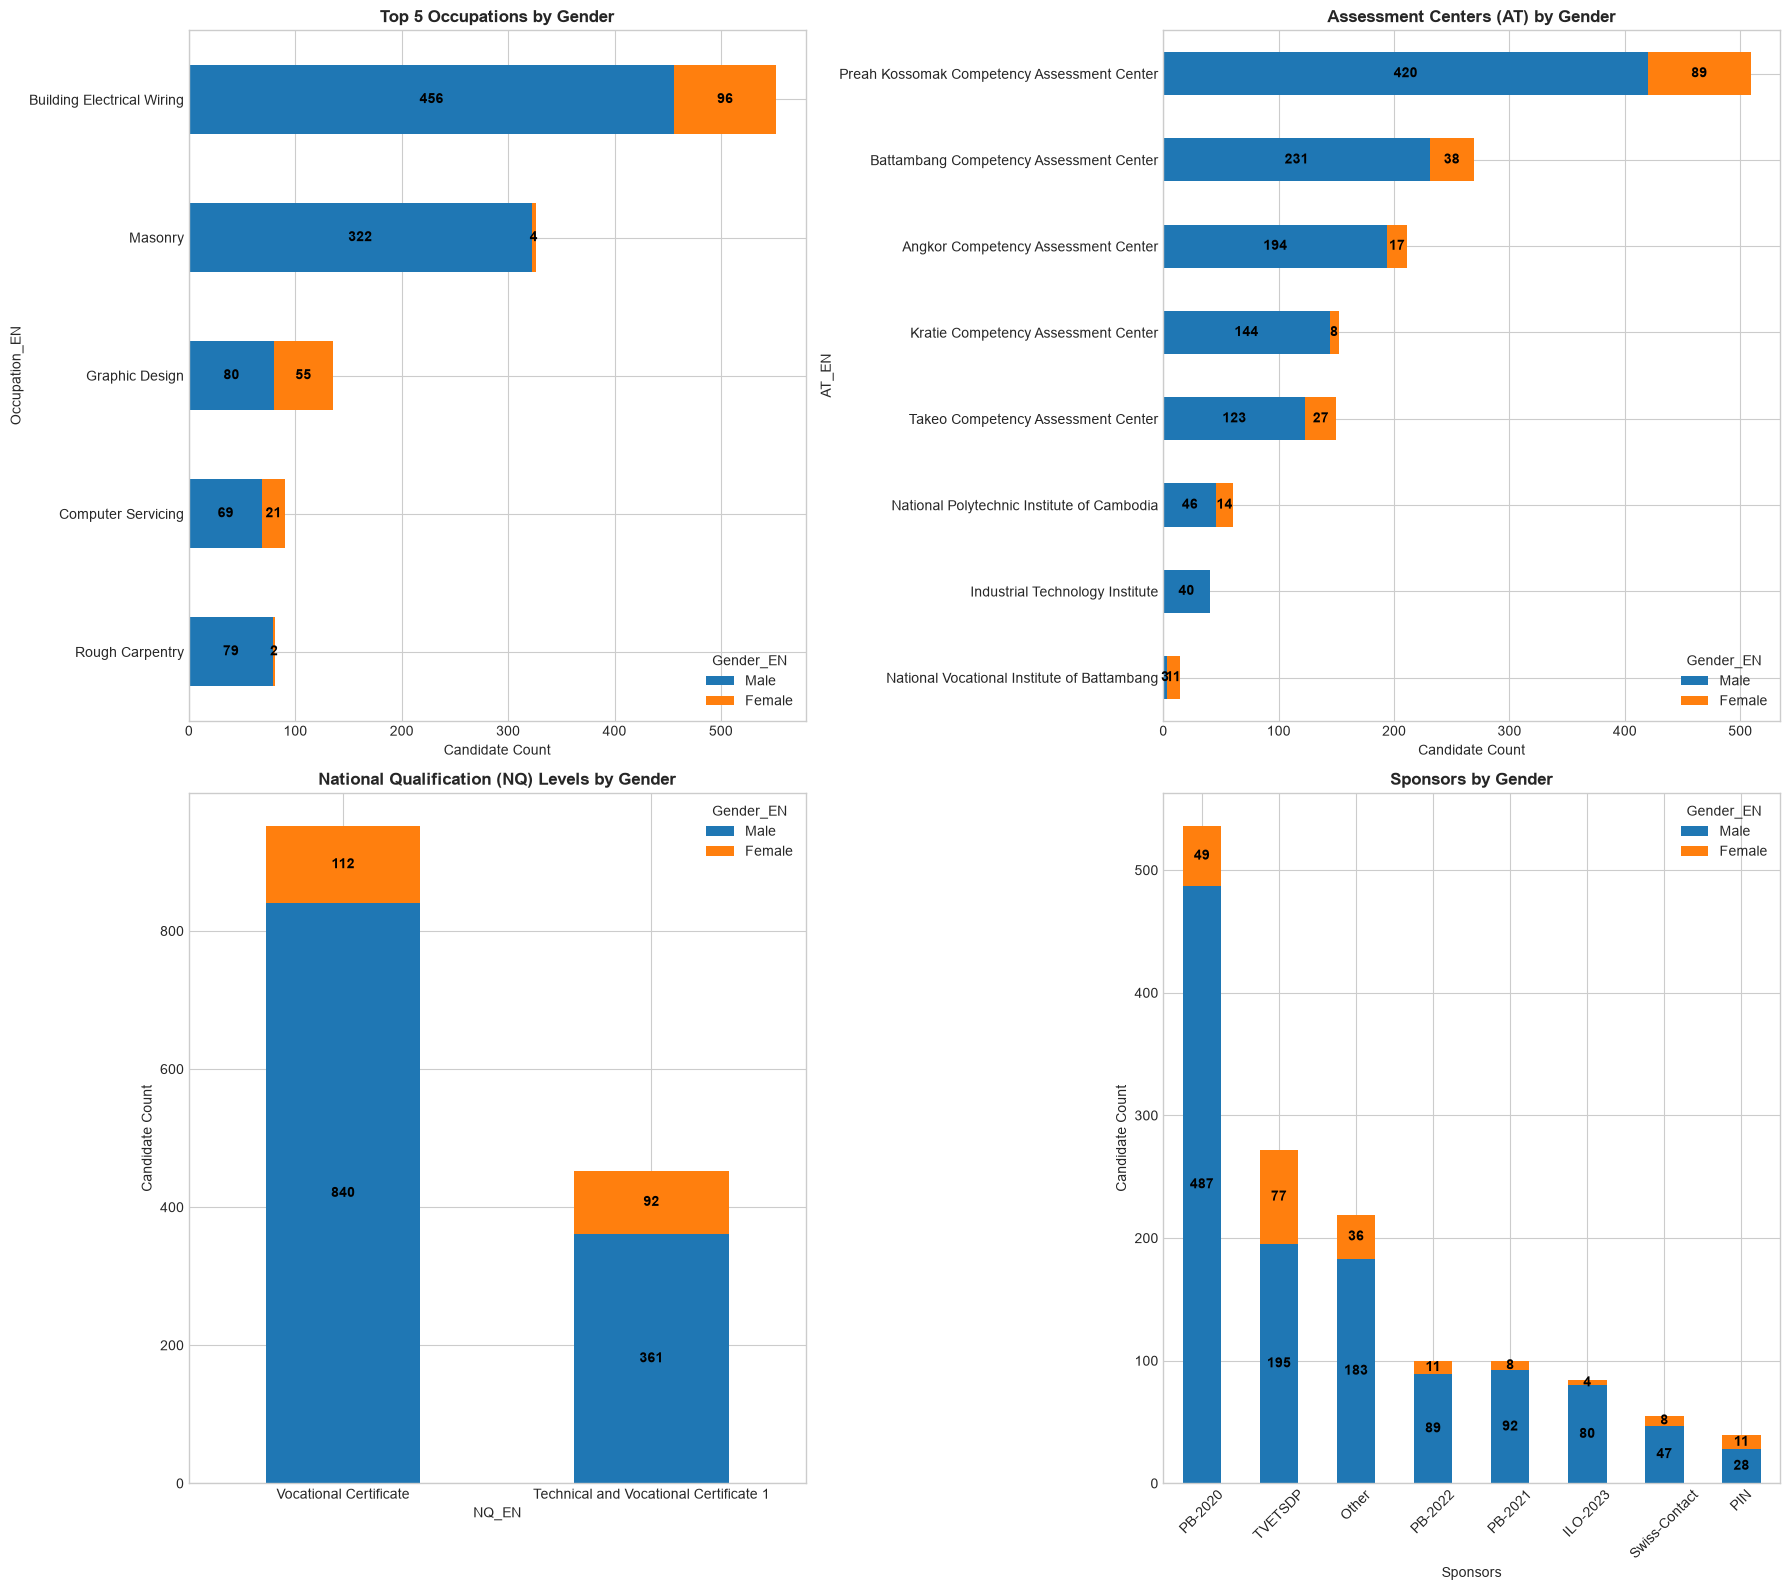

In [114]:
fig, axes = plt.subplots(2, 2, figsize=(18, 16))

# 1. Top 5 Occupations
top_occ = occ_en_ct.drop('Total').head(5)[['Male', 'Female']]
ax1 = top_occ.plot(kind='barh', stacked=True, ax=axes[0, 0], color=['#1f77b4', '#ff7f0e'])
axes[0, 0].set_title('Top 5 Occupations by Gender', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Candidate Count')
axes[0, 0].invert_yaxis()
for c in ax1.containers:
    labels = [f'{int(v):,}' if v > 0 else '' for v in c.datavalues]
    ax1.bar_label(c, labels=labels, label_type='center', fontsize=10, fontweight='bold', color='black')

# 2. Assessment Centers
at_data = at_en_ct.drop('Total')[['Male', 'Female']]
ax2 = at_data.plot(kind='barh', stacked=True, ax=axes[0, 1], color=['#1f77b4', '#ff7f0e'])
axes[0, 1].set_title('Assessment Centers (AT) by Gender', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Candidate Count')
axes[0, 1].invert_yaxis()
for c in ax2.containers:
    labels = [f'{int(v):,}' if v > 0 else '' for v in c.datavalues]
    ax2.bar_label(c, labels=labels, label_type='center', fontsize=10, fontweight='bold', color='black')

# 3. National Qualification (NQ) Levels
nq_data = nq_en_ct.drop('Total')[['Male', 'Female']]
ax3 = nq_data.plot(kind='bar', stacked=True, ax=axes[1, 0], color=['#1f77b4', '#ff7f0e'])
axes[1, 0].set_title('National Qualification (NQ) Levels by Gender', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Candidate Count')
axes[1, 0].tick_params(axis='x', rotation=0)
for c in ax3.containers:
    labels = [f'{int(v):,}' if v > 0 else '' for v in c.datavalues]
    ax3.bar_label(c, labels=labels, label_type='center', fontsize=10, fontweight='bold', color='black')

# 4. Top Sponsors
sponsor_data = sp_en_ct.drop('Total')[['Male', 'Female']]
ax4 = sponsor_data.plot(kind='bar', stacked=True, ax=axes[1, 1], color=['#1f77b4', '#ff7f0e'])
axes[1, 1].set_title('Sponsors by Gender', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('Candidate Count')
axes[1, 1].tick_params(axis='x', rotation=45)
for c in ax4.containers:
    labels = [f'{int(v):,}' if v > 0 else '' for v in c.datavalues]
    ax4.bar_label(c, labels=labels, label_type='center', fontsize=10, fontweight='bold', color='black')

plt.tight_layout()
plt.show()

## 5. Annual Breakdown & Gender Divergence Trends across Dimensions (2020–2023)
Comprehensive analysis featuring **Stacked Area Charts**, **segment numerical labels**, **annual total annotations**, and **Male vs Female divergence** across all key category dimensions.

### 5.1 Annual Candidate Volume & Gender Trend (2020 - 2023)
Comparing annual candidate volume and gender composition (Male vs Female) across years with data labels and percentage annotations.

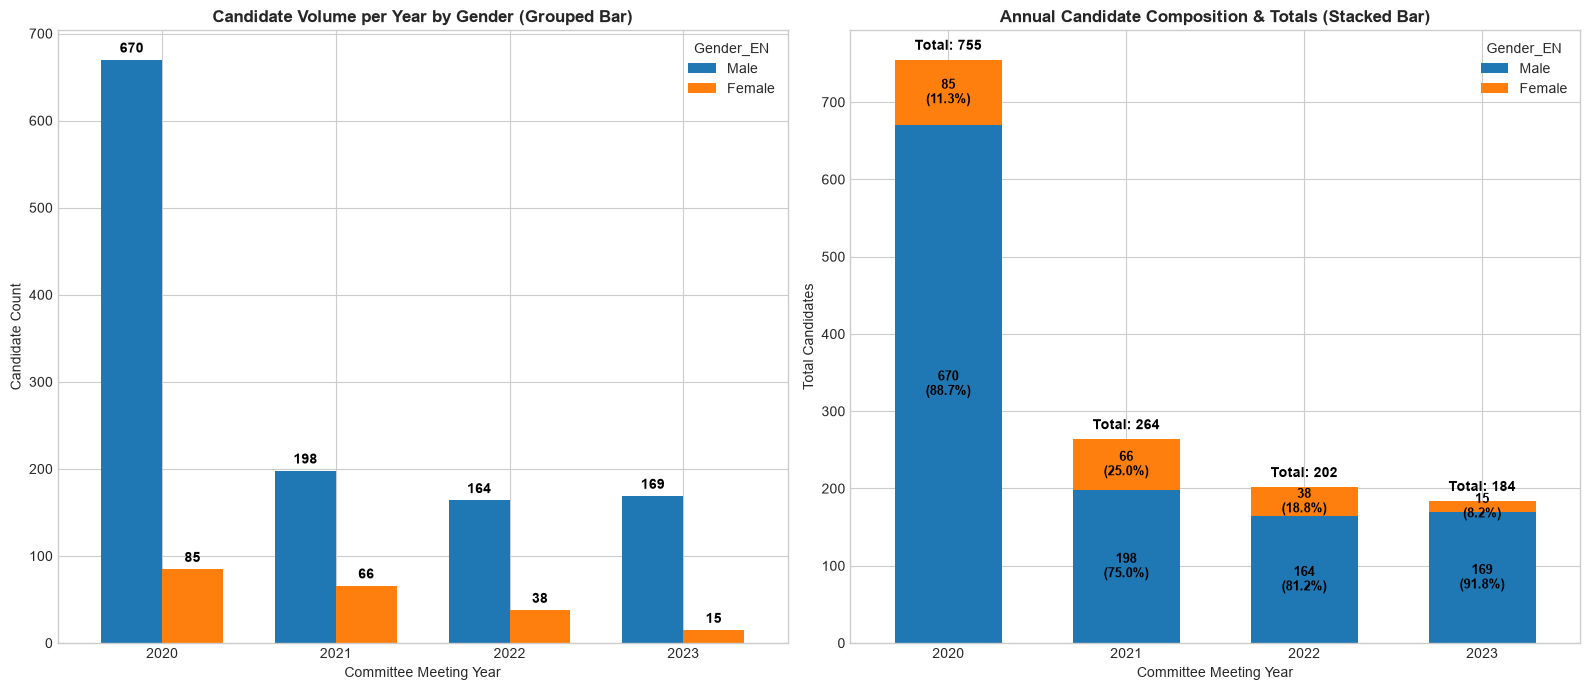

In [115]:
# Annual Candidate Distribution & Trend Visualizations by Gender
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

year_gender = pd.crosstab(df_en['CM_Year'], df_en['Gender_EN'])[['Male', 'Female']]

# Subplot 1: Grouped Bar Chart
ax_year1 = year_gender.plot(kind='bar', ax=axes[0], color=['#1f77b4', '#ff7f0e'], width=0.7)
axes[0].set_title('Candidate Volume per Year by Gender (Grouped Bar)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Committee Meeting Year')
axes[0].set_ylabel('Candidate Count')
axes[0].tick_params(axis='x', rotation=0)

for c in ax_year1.containers:
    labels = [f'{int(v):,}' if v > 0 else '' for v in c.datavalues]
    ax_year1.bar_label(c, labels=labels, label_type='edge', fontsize=10, fontweight='bold', color='black', padding=3)

# Subplot 2: Stacked Bar Chart with Percentage Composition & Totals
ax_year2 = year_gender.plot(kind='bar', stacked=True, ax=axes[1], color=['#1f77b4', '#ff7f0e'], width=0.6)
axes[1].set_title('Annual Candidate Composition & Totals (Stacked Bar)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Committee Meeting Year')
axes[1].set_ylabel('Total Candidates')
axes[1].tick_params(axis='x', rotation=0)

for c in ax_year2.containers:
    for bar in c:
        height = bar.get_height()
        if height > 0:
            x_pos = int(round(bar.get_x() + bar.get_width() / 2))
            year_val = year_gender.index[x_pos]
            total_yr = year_gender.loc[year_val].sum()
            pct = (height / total_yr) * 100
            ax_year2.annotate(f'{int(height):,}\n({pct:.1f}%)',
                              xy=(bar.get_x() + bar.get_width() / 2, bar.get_y() + height / 2),
                              ha='center', va='center', fontsize=9, fontweight='bold', color='black')

for year_idx, (year, row) in enumerate(year_gender.iterrows()):
    tot = row.sum()
    axes[1].annotate(f'Total: {tot:,}',
                     xy=(year_idx, tot),
                     xytext=(0, 5), textcoords="offset points",
                     ha='center', va='bottom', fontweight='bold', color='black', fontsize=10)

plt.tight_layout()
plt.show()

### 5.2 Category Breakdown Trends by Year (Occupations, Assessment Centers, NQ Levels & Sponsors)
Visualizing annual distribution across **all Occupations**, **all Assessment Centers**, **Qualification Levels**, and **all Sponsors** per year (2020–2023) using **Top-to-Bottom (Vertical Column) Charts** with **legends positioned outside the plot area** and **exact numerical labels** on each segment.

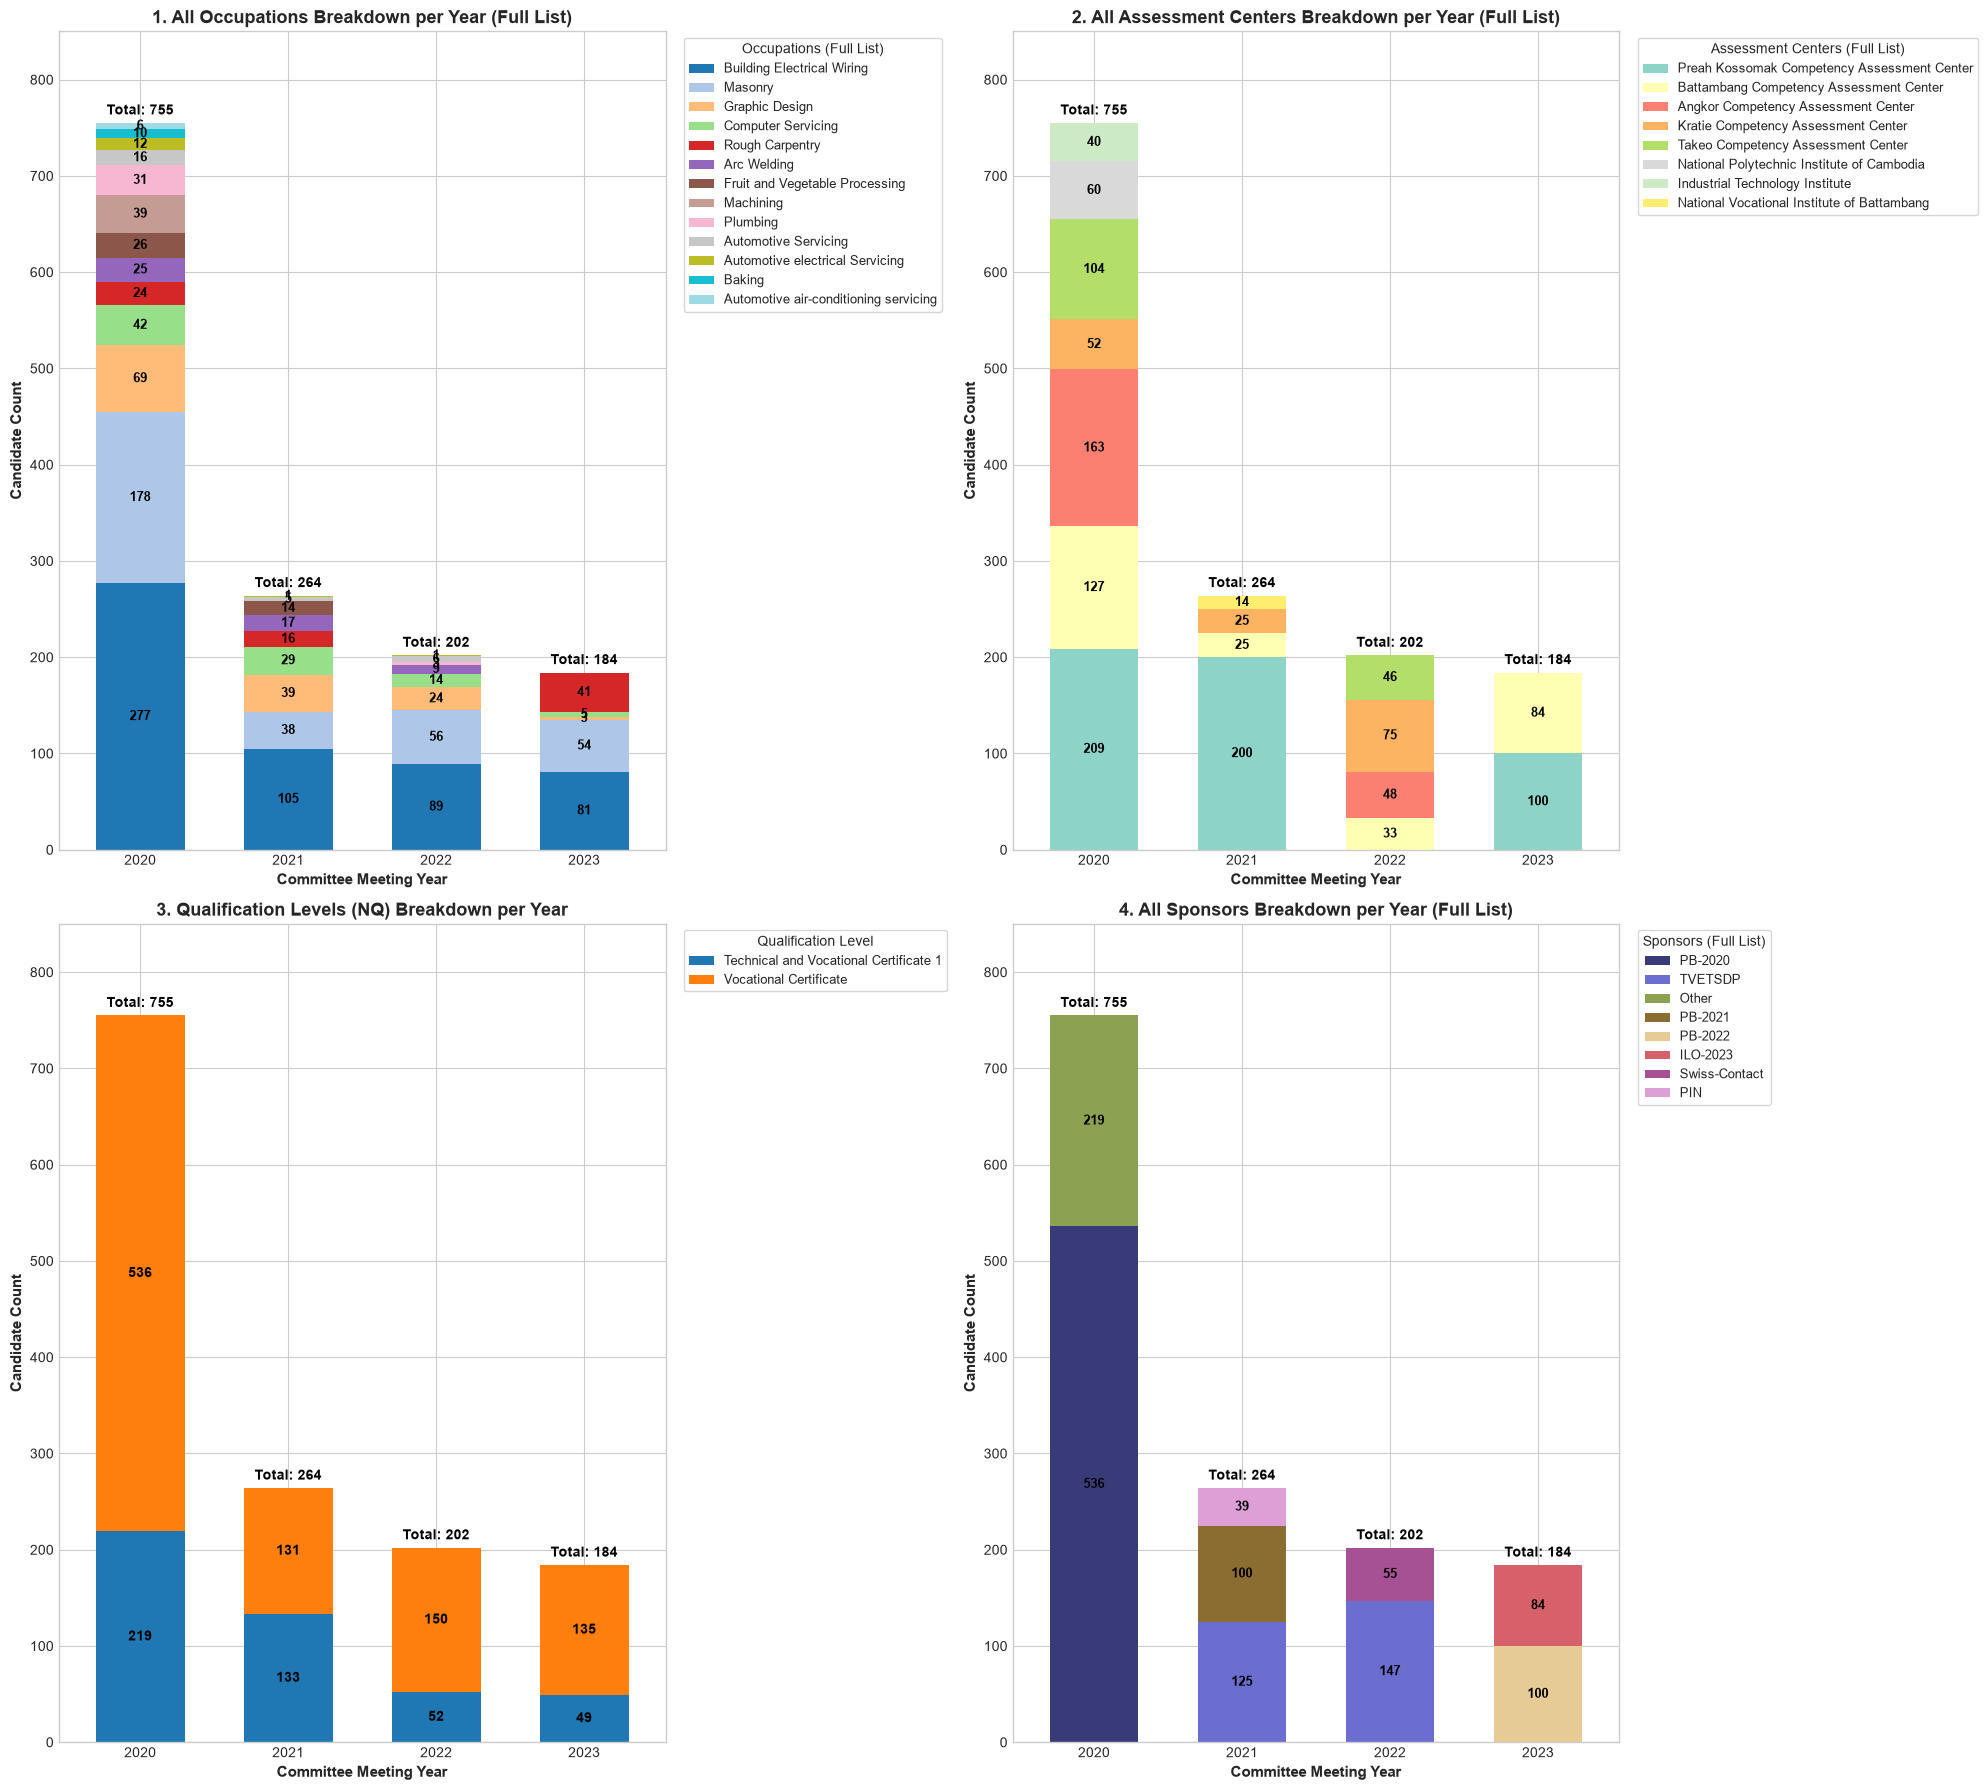

In [116]:
# Annual Breakdown Visualizations across Dimensions by Year (Top-to-Bottom Vertical Column Charts with External Legends & Taller Figure)
fig, axes = plt.subplots(2, 2, figsize=(20, 18))

# 1. All Occupations Breakdown by Year (Top-to-Bottom Vertical Stacked Columns)
occ_yr = pd.crosstab(df_en['Occupation_EN'], df_en['CM_Year'])
all_occs = occ_yr.sum(axis=1).sort_values(ascending=False).index
occ_yr_all = occ_yr.loc[all_occs].T # X-axis = Years (2020, 2021, 2022, 2023)

ax1 = occ_yr_all.plot(kind='bar', stacked=True, ax=axes[0, 0], colormap='tab20', width=0.6)
axes[0, 0].set_title('1. All Occupations Breakdown per Year (Full List)', fontsize=13, fontweight='bold')
axes[0, 0].set_xlabel('Committee Meeting Year', fontsize=11, fontweight='bold')
axes[0, 0].set_ylabel('Candidate Count', fontsize=11, fontweight='bold')
axes[0, 0].tick_params(axis='x', rotation=0)
axes[0, 0].set_ylim(0, 850)
axes[0, 0].legend(title='Occupations (Full List)', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=True, fontsize=9)

for c in ax1.containers:
    labels = [f'{int(v):,}' if v > 0 else '' for v in c.datavalues]
    ax1.bar_label(c, labels=labels, label_type='center', fontsize=9, fontweight='bold', color='black')

for yr_idx, yr in enumerate(occ_yr_all.index):
    tot = occ_yr_all.loc[yr].sum()
    axes[0, 0].annotate(f'Total: {tot:,}', xy=(yr_idx, tot), xytext=(0, 4),
                        textcoords='offset points', ha='center', va='bottom', fontweight='bold', color='black')

# 2. All Assessment Centers Breakdown by Year (Top-to-Bottom Vertical Stacked Columns)
at_yr = pd.crosstab(df_en['AT_EN'], df_en['CM_Year'])
all_at = at_yr.sum(axis=1).sort_values(ascending=False).index
at_yr_all = at_yr.loc[all_at].T

ax2 = at_yr_all.plot(kind='bar', stacked=True, ax=axes[0, 1], colormap='Set3', width=0.6)
axes[0, 1].set_title('2. All Assessment Centers Breakdown per Year (Full List)', fontsize=13, fontweight='bold')
axes[0, 1].set_xlabel('Committee Meeting Year', fontsize=11, fontweight='bold')
axes[0, 1].set_ylabel('Candidate Count', fontsize=11, fontweight='bold')
axes[0, 1].tick_params(axis='x', rotation=0)
axes[0, 1].set_ylim(0, 850)
axes[0, 1].legend(title='Assessment Centers (Full List)', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=True, fontsize=9)

for c in ax2.containers:
    labels = [f'{int(v):,}' if v > 0 else '' for v in c.datavalues]
    ax2.bar_label(c, labels=labels, label_type='center', fontsize=9, fontweight='bold', color='black')

for yr_idx, yr in enumerate(at_yr_all.index):
    tot = at_yr_all.loc[yr].sum()
    axes[0, 1].annotate(f'Total: {tot:,}', xy=(yr_idx, tot), xytext=(0, 4),
                        textcoords='offset points', ha='center', va='bottom', fontweight='bold', color='black')

# 3. Qualification Levels (NQ) Breakdown by Year (Top-to-Bottom Vertical Stacked Columns)
nq_yr = pd.crosstab(df_en['NQ_EN'], df_en['CM_Year']).T
ax3 = nq_yr.plot(kind='bar', stacked=True, ax=axes[1, 0], color=['#1f77b4', '#ff7f0e'], width=0.6)
axes[1, 0].set_title('3. Qualification Levels (NQ) Breakdown per Year', fontsize=13, fontweight='bold')
axes[1, 0].set_xlabel('Committee Meeting Year', fontsize=11, fontweight='bold')
axes[1, 0].set_ylabel('Candidate Count', fontsize=11, fontweight='bold')
axes[1, 0].tick_params(axis='x', rotation=0)
axes[1, 0].set_ylim(0, 850)
axes[1, 0].legend(title='Qualification Level', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=True, fontsize=9)

for c in ax3.containers:
    labels = [f'{int(v):,}' if v > 0 else '' for v in c.datavalues]
    ax3.bar_label(c, labels=labels, label_type='center', fontsize=10, fontweight='bold', color='black')

for yr_idx, yr in enumerate(nq_yr.index):
    tot = nq_yr.loc[yr].sum()
    axes[1, 0].annotate(f'Total: {tot:,}', xy=(yr_idx, tot), xytext=(0, 4),
                        textcoords='offset points', ha='center', va='bottom', fontweight='bold', color='black')

# 4. All Sponsors Breakdown by Year (Top-to-Bottom Vertical Stacked Columns)
sp_yr = pd.crosstab(df_en['Sponsors'], df_en['CM_Year'])
all_sp = sp_yr.sum(axis=1).sort_values(ascending=False).index
sp_yr_all = sp_yr.loc[all_sp].T

ax4 = sp_yr_all.plot(kind='bar', stacked=True, ax=axes[1, 1], colormap='tab20b', width=0.6)
axes[1, 1].set_title('4. All Sponsors Breakdown per Year (Full List)', fontsize=13, fontweight='bold')
axes[1, 1].set_xlabel('Committee Meeting Year', fontsize=11, fontweight='bold')
axes[1, 1].set_ylabel('Candidate Count', fontsize=11, fontweight='bold')
axes[1, 1].tick_params(axis='x', rotation=0)
axes[1, 1].set_ylim(0, 850)
axes[1, 1].legend(title='Sponsors (Full List)', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=True, fontsize=9)

for c in ax4.containers:
    labels = [f'{int(v):,}' if v > 0 else '' for v in c.datavalues]
    ax4.bar_label(c, labels=labels, label_type='center', fontsize=9, fontweight='bold', color='black')

for yr_idx, yr in enumerate(sp_yr_all.index):
    tot = sp_yr_all.loc[yr].sum()
    axes[1, 1].annotate(f'Total: {tot:,}', xy=(yr_idx, tot), xytext=(0, 4),
                        textcoords='offset points', ha='center', va='bottom', fontweight='bold', color='black')

plt.tight_layout()
plt.show()

### 5.3 Gender Divergence Breakdown across Category Dimensions (Male vs Female per Subject per Year)
Visualizing the exact **Male vs Female candidate divergence** per Subject per Year across every Occupation, Assessment Center, NQ Level, and Sponsor using Top-to-Bottom vertical column charts with **legends positioned outside**, **bold black labels**, and **taller figure proportions**.

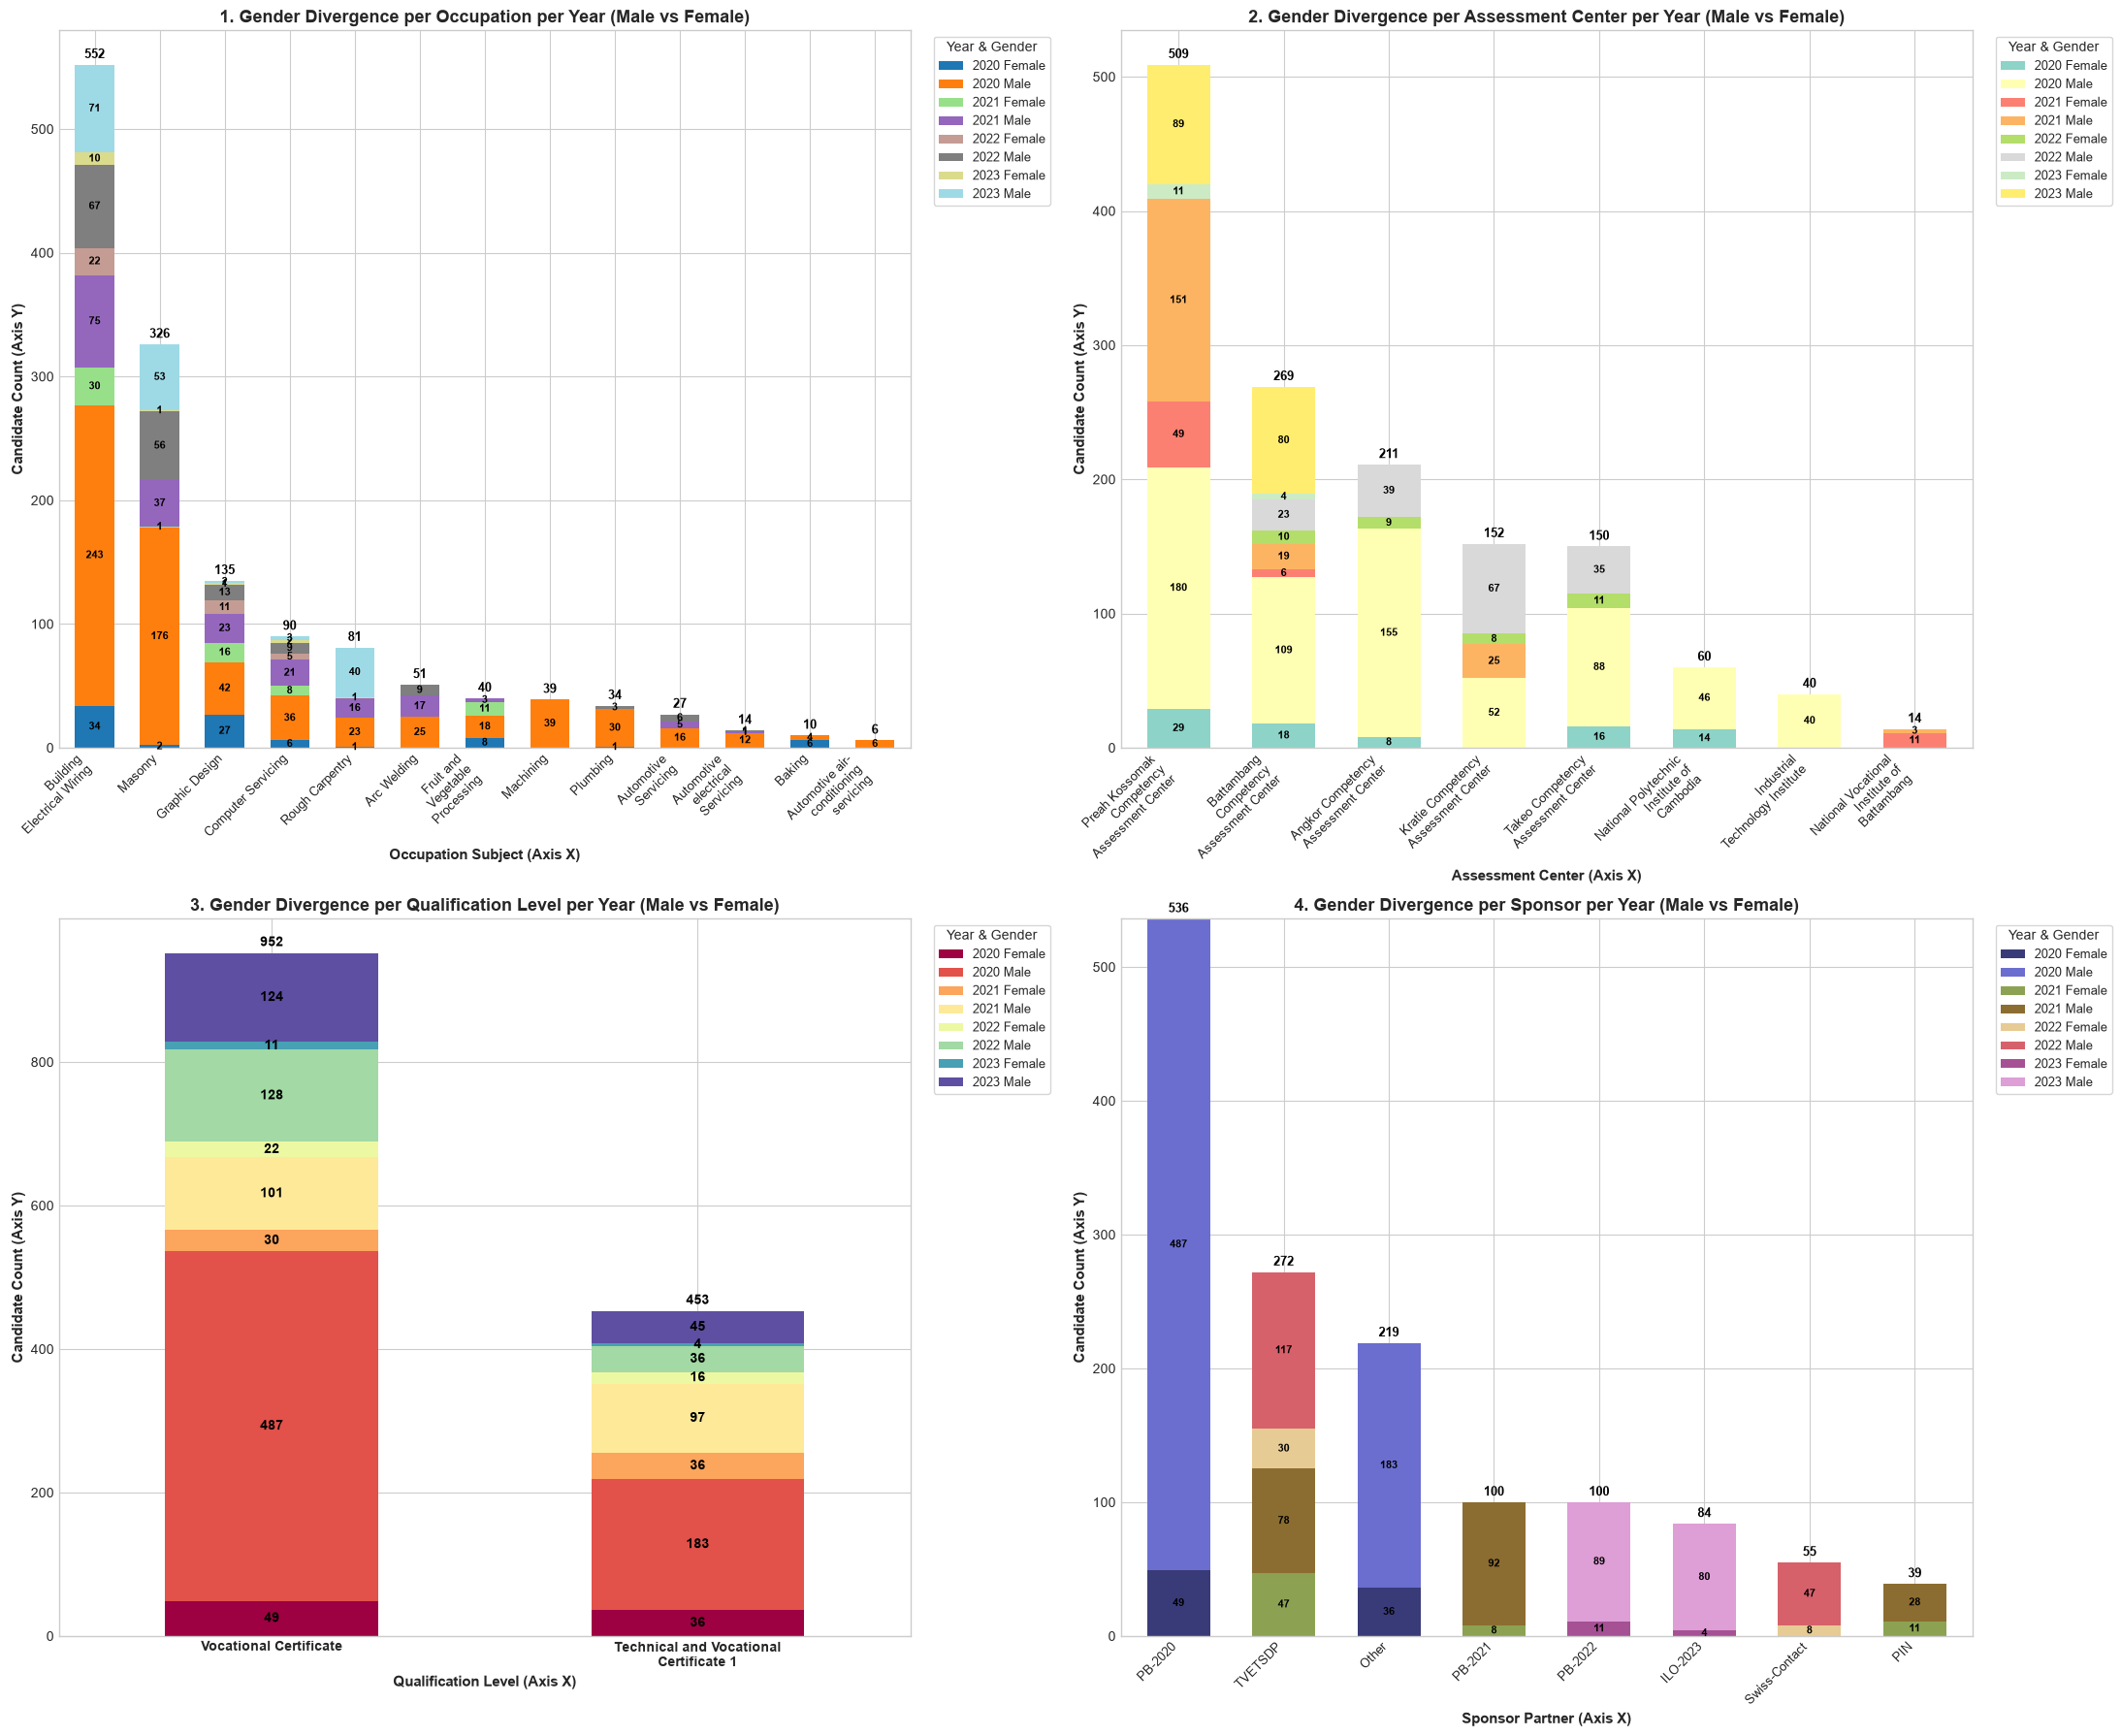

In [117]:
import textwrap

# 5.3 Gender Divergence Breakdown across Category Dimensions (Male vs Female per Subject per Year)
fig, axes = plt.subplots(2, 2, figsize=(22, 18))

# 1. Occupations Gender Divergence per Subject per Year
occ_sub_yr_gen = pd.crosstab(df_en['Occupation_EN'], [df_en['CM_Year'], df_en['Gender_EN']])
all_occs = occ_sub_yr_gen.sum(axis=1).sort_values(ascending=False).index
occ_sub_yr_gen = occ_sub_yr_gen.loc[all_occs]
occ_sub_yr_gen.columns = [f"{yr} {gen}" for yr, gen in occ_sub_yr_gen.columns]

ax1 = occ_sub_yr_gen.plot(kind='bar', stacked=True, ax=axes[0, 0], colormap='tab20', width=0.6)
axes[0, 0].set_title('1. Gender Divergence per Occupation per Year (Male vs Female)', fontsize=13, fontweight='bold')
axes[0, 0].set_xlabel('Occupation Subject (Axis X)', fontsize=11, fontweight='bold')
axes[0, 0].set_ylabel('Candidate Count (Axis Y)', fontsize=11, fontweight='bold')
axes[0, 0].set_xticklabels([textwrap.fill(label.get_text(), 18) for label in axes[0, 0].get_xticklabels()], rotation=45, ha='right', fontsize=9)
axes[0, 0].legend(title='Year & Gender', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=True, fontsize=9)

for c in ax1.containers:
    labels = [f'{int(v):,}' if v > 0 else '' for v in c.datavalues]
    ax1.bar_label(c, labels=labels, label_type='center', fontsize=8, fontweight='bold', color='black')

for idx, occ in enumerate(occ_sub_yr_gen.index):
    tot = occ_sub_yr_gen.loc[occ].sum()
    axes[0, 0].annotate(f'{tot:,}', xy=(idx, tot), xytext=(0, 3),
                        textcoords='offset points', ha='center', va='bottom', fontweight='bold', color='black', fontsize=9)

# 2. Assessment Centers Gender Divergence per Subject per Year
at_sub_yr_gen = pd.crosstab(df_en['AT_EN'], [df_en['CM_Year'], df_en['Gender_EN']])
all_at = at_sub_yr_gen.sum(axis=1).sort_values(ascending=False).index
at_sub_yr_gen = at_sub_yr_gen.loc[all_at]
at_sub_yr_gen.columns = [f"{yr} {gen}" for yr, gen in at_sub_yr_gen.columns]

ax2 = at_sub_yr_gen.plot(kind='bar', stacked=True, ax=axes[0, 1], colormap='Set3', width=0.6)
axes[0, 1].set_title('2. Gender Divergence per Assessment Center per Year (Male vs Female)', fontsize=13, fontweight='bold')
axes[0, 1].set_xlabel('Assessment Center (Axis X)', fontsize=11, fontweight='bold')
axes[0, 1].set_ylabel('Candidate Count (Axis Y)', fontsize=11, fontweight='bold')
axes[0, 1].set_xticklabels([textwrap.fill(label.get_text(), 20) for label in axes[0, 1].get_xticklabels()], rotation=45, ha='right', fontsize=9)
axes[0, 1].legend(title='Year & Gender', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=True, fontsize=9)

for c in ax2.containers:
    labels = [f'{int(v):,}' if v > 0 else '' for v in c.datavalues]
    ax2.bar_label(c, labels=labels, label_type='center', fontsize=8, fontweight='bold', color='black')

for idx, at in enumerate(at_sub_yr_gen.index):
    tot = at_sub_yr_gen.loc[at].sum()
    axes[0, 1].annotate(f'{tot:,}', xy=(idx, tot), xytext=(0, 3),
                        textcoords='offset points', ha='center', va='bottom', fontweight='bold', color='black', fontsize=9)

# 3. Qualification Levels (NQ) Gender Divergence per Subject per Year
nq_sub_yr_gen = pd.crosstab(df_en['NQ_EN'], [df_en['CM_Year'], df_en['Gender_EN']])
all_nq = nq_sub_yr_gen.sum(axis=1).sort_values(ascending=False).index
nq_sub_yr_gen = nq_sub_yr_gen.loc[all_nq]
nq_sub_yr_gen.columns = [f"{yr} {gen}" for yr, gen in nq_sub_yr_gen.columns]

ax3 = nq_sub_yr_gen.plot(kind='bar', stacked=True, ax=axes[1, 0], colormap='Spectral', width=0.5)
axes[1, 0].set_title('3. Gender Divergence per Qualification Level per Year (Male vs Female)', fontsize=13, fontweight='bold')
axes[1, 0].set_xlabel('Qualification Level (Axis X)', fontsize=11, fontweight='bold')
axes[1, 0].set_ylabel('Candidate Count (Axis Y)', fontsize=11, fontweight='bold')
axes[1, 0].set_xticklabels([textwrap.fill(label.get_text(), 25) for label in axes[1, 0].get_xticklabels()], rotation=0, fontsize=10, fontweight='bold')
axes[1, 0].legend(title='Year & Gender', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=True, fontsize=9)

for c in ax3.containers:
    labels = [f'{int(v):,}' if v > 0 else '' for v in c.datavalues]
    ax3.bar_label(c, labels=labels, label_type='center', fontsize=10, fontweight='bold', color='black')

for idx, nq in enumerate(nq_sub_yr_gen.index):
    tot = nq_sub_yr_gen.loc[nq].sum()
    axes[1, 0].annotate(f'{tot:,}', xy=(idx, tot), xytext=(0, 3),
                        textcoords='offset points', ha='center', va='bottom', fontweight='bold', color='black', fontsize=10)

# 4. Sponsors Gender Divergence per Subject per Year
sp_sub_yr_gen = pd.crosstab(df_en['Sponsors'], [df_en['CM_Year'], df_en['Gender_EN']])
all_sp = sp_sub_yr_gen.sum(axis=1).sort_values(ascending=False).index
sp_sub_yr_gen = sp_sub_yr_gen.loc[all_sp]
sp_sub_yr_gen.columns = [f"{yr} {gen}" for yr, gen in sp_sub_yr_gen.columns]

ax4 = sp_sub_yr_gen.plot(kind='bar', stacked=True, ax=axes[1, 1], colormap='tab20b', width=0.6)
axes[1, 1].set_title('4. Gender Divergence per Sponsor per Year (Male vs Female)', fontsize=13, fontweight='bold')
axes[1, 1].set_xlabel('Sponsor Partner (Axis X)', fontsize=11, fontweight='bold')
axes[1, 1].set_ylabel('Candidate Count (Axis Y)', fontsize=11, fontweight='bold')
axes[1, 1].set_xticklabels(axes[1, 1].get_xticklabels(), rotation=45, ha='right', fontsize=9)
axes[1, 1].legend(title='Year & Gender', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=True, fontsize=9)

for c in ax4.containers:
    labels = [f'{int(v):,}' if v > 0 else '' for v in c.datavalues]
    ax4.bar_label(c, labels=labels, label_type='center', fontsize=8, fontweight='bold', color='black')

for idx, sp in enumerate(sp_sub_yr_gen.index):
    tot = sp_sub_yr_gen.loc[sp].sum()
    axes[1, 1].annotate(f'{tot:,}', xy=(idx, tot), xytext=(0, 3),
                        textcoords='offset points', ha='center', va='bottom', fontweight='bold', color='black', fontsize=9)

plt.tight_layout()
plt.show()

## 6. Key Exploratory Findings & Summary

1. **Overall Gender Distribution:**
   - **Total Candidates:** 1,405 (100.0%)
   - **Male (`Male` / `ប្រុស`):** 1,201 candidates (**85.48%**)
   - **Female (`Female` / `ស្រី`):** 204 candidates (**14.52%**)

2. **Dual DataFrame Structure:**
   - **`df_kh`**: Cleaned dataset using Khmer (`KH`) attributes for internal data analysis and exploration.
   - **`df_en`**: Cleaned dataset dropping KH attributes (`Occupation_KH`, `NQ_KH`, `AT_KH`, `Gender_KH`) for visualization charts and English summary tables.

3. **Annual Candidate Trends across Dimensions (2020 - 2023):**
   - **2020 Peak Volume:** 755 candidates (670 Male, 85 Female - 11.3% Female). Top occupation: *Building Electrical Wiring* (277 candidates).
   - **2021:** 264 candidates (198 Male, 66 Female - 25.0% Female). Top sponsor: *TVETSDP* (125) & *PB-2021* (100).
   - **2022:** 202 candidates (164 Male, 38 Female - 18.8% Female). Top center: *Kratie Assessment Center* (75).
   - **2023:** 184 candidates (169 Male, 15 Female - 8.2% Female). Top sponsor: *PB-2022* (100) & *ILO-2023* (84).

4. **Key Dimension Breakdown & Gender Divergence Insights:**
   - **Top Occupation:** Building Electrical Wiring / ការដំឡើងបណ្តាញអគ្គិសនីក្នុងអគារ (552 total: 456 Male, 96 Female)
   - **Top Assessment Center:** Preah Kossomak / មជ្ឈមណ្ឌលវាយតម្លៃសមត្ថភាពព្រះកុសុមៈ (509 total: 420 Male, 89 Female)
   - **Top Qualification Level:** Vocational Certificate / វិញ្ញាបនបត្រវិជ្ជាជីវៈ (952 total: 840 Male, 112 Female)
   - **Top Sponsor:** PB-2020 (536 total: 487 Male, 49 Female)